<h1 style="text-align:center">Muon Scattering Angle Analysis for MCS </h1>

<p style="text-align:center"> Analyzing muon scattering angle distributions using gaussians and double-gaussian functions to study effectivess of MCS energy estimation.</p>

<p style="text-align:center"> NOTICE: Open this notebook using likelihoodpid venv.</p>

# 1. import and open files

In [2]:
import os
import re

from multiprocessing import Pool, cpu_count
from scipy import stats
from tqdm.auto import tqdm

import ROOT
from ROOT import TMath, TF1, TCanvas, TFormula
from ROOT import gROOT, gObjectTable
from array import array
#import uproot
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

import pickle

from scipy.interpolate import CubicSpline
from scipy import stats
from scipy import integrate
import math
    

/home/sungbino/py/likelihoodpid/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
version = "v10_14_02_02"

In [4]:
input_file1 = "/home/xpuig/cafpyana/mcs_df_test.df"
input_file2 = "/home/xpuig/mcs_df_gen2_mc_part.df"

print("keys")
#splh.print_keys(input_file)

keys


# 2. Using PyROOT to graph a Gaussian and Double Gaussian

In [5]:
# Read the muon trajectory dataframe

muon_df = pd.read_hdf(input_file1, key="muon_traj_0")
muon_gen2 = pd.read_hdf(input_file2, key="muon_traj_0")

#Finding energies at each breakpoint
muonEnergies = []
momenta = muon_gen2["resranges_mid_mean_P"]
bp = 0
mu_mass = .1057 #GeV/c^2
numRows = momenta.shape[0]
plist = []
eType = []
while bp < numRows:
    p = momenta.values[bp]
    plist.append(p)
    E = (((p**2.)+(mu_mass**2.))**0.5) # E^2 = p^2c^2+(mc^2)^2 (Energy-momentum formula). c=1, so E = sqrt(p^2+m^2)
    Efloat = E.item()
    muonEnergies.append(Efloat)
    
    bp += 1

muon_gen2

dtheta  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
5        62    1              0                       0            43.361172   
                                                      1            62.752671   
                                                      2            42.946860   
                                                      3           137.712507   
                                                      4            38.463992   
...                                                                      ...   
184      3165  1              0                       2            50.111951   
                                                      3            78.182984   
                                                      4            93.154430   
                                                      5            93.616910   
                                                      6           237.756779   

                                                                  dtheta_xz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint              
5        62    1              0                       0           37.543827   
                                                      1           52.366103   
                                                      2          -12.404376   
                                                      3          -95.958205   
                                                      4           43.780477   
...                                                                     ...   
184      3165  1              0                       2          -54.225610   
                                                      3          -12.776234   
                                                      4          -51.965788   
                                                      5           99.892445   
                                                      6           59.375486   

                                                                   dtheta_yz  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint               
5        62    1              0                       0           -46.267680   
                                                      1           -66.562001   
                                                      2           -37.272612   
                                                      3           -84.877744   
                                                      4           -34.478986   
...                                                                      ...   
184      3165  1              0                       2            42.689668   
                                                      3           -87.447020   
                                                      4           -63.761889   
                                                      5           -15.400205   
                                                      6           263.292618   

                                                                  angle_xz_rot  \
__ntuple entry rec.slc..index rec.slc.reco.pfp..index breakpoint                 
5        62    1              0                       0             -42.196264   
                                                      1             -60.237114   
                                                      2             -38.596782   
                                                      3             -94.923867   
                                                      4             -25.246770   
...                                                                        ...   
184      3165  1              0                       2              17.263957   
                                                      3             -73.648599   
                                                      4             -70.062505   
                                                      5   

In [6]:
def th1_from_series(series, name=r"$d\theta_{xz}$", title="dQ/dx;dQ/dx [A.U./cm];Counts",
                    nbins=100, xmin=-250.0, xmax=250.0, weights=None, edges=None):
    # drop NaNs
    vals = series.to_numpy(dtype=float)
    vals = vals[~np.isnan(vals)]
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        w = w[~np.isnan(series.to_numpy())]
    else:
        w = None

    # binning
    if edges is None:
        edges = np.linspace(xmin, xmax, nbins + 1)
    else:
        edges = np.asarray(edges, dtype=float)
        nbins = len(edges) - 1

    # histogram with numpy
    counts, edges = np.histogram(vals, bins=edges, weights=w)

    # make TH1 with variable binning
    h = ROOT.TH1F(name, title, nbins, array('d', edges))
    h.Sumw2()
    for i, c in enumerate(counts, start=1):
        h.SetBinContent(i, float(c))
        # Set sqrt(N) if unweighted; else keep Sumw2 weights
        if w is None:
            h.SetBinError(i, np.sqrt(c))
    return h

In [7]:
ROOT.gInterpreter.Declare(r"""
#include "TMath.h"
double gaus_cpp(double *x, double *p) {
  const double A = p[0];
  const double mu = p[1];
  const double sig = p[2];

  if (sig <= 0) return 0.0;

  return A*exp(-0.5*(pow(((x[0]-mu)/sig),2)));
} 

double double_gaus_cpp(double *x, double *p) {
  return gaus_cpp(x, p) + gaus_cpp(x, p+3); 
}  
                          
double double_gaus_norm(double *x, double *p) {
  const double scale = p[0];
  const double A = p[1];
  const double mu1 = p[2];
  const double sig1 = p[3];
  const double mu2 = p[4];
  const double sig2 = p[5];

  return scale*A*exp(-0.5*(pow(((x[0]-mu1)/sig1),2)))+scale*(1-A)*exp(-0.5*(pow(((x[0]-mu2)/sig2),2)));                                                
}                                                              
""")

True

<h2 style="text-align: center">Single Gaussian</h2>

In [8]:
def gaus_fit(df, column, energyBounds = [0.1,0.3], name="gaus",nbins=1000):
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > e1 and muonEnergies[counter] < e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.gaus_cpp, -500, 500, 3) #Create gaussian function with 3 parameters
    func1.SetParameters(0.78, 0.452, 95)
    h_dtheta_xz = th1_from_series(seriesNew, name=name) #Making TH1 Object to fit to the data


    h_dtheta_xz.Fit(func1, "S") #Fitting the gaussian function to the data
    area,mu,sigma = func1.GetParameter(0), func1.GetParameter(1), func1.GetParameter(2) #Getting the parameters of the fitted gaussian function

    bin_heights, bin_borders, _ = plt.hist(seriesNew, bins=nbins, range=(-500, 500), label='Fitted Gaussian', color='skyblue',log=True)
    norm = len(seriesNew) * (bin_borders[1] - bin_borders[0])

    x = np.linspace(-500, 500, nbins)
    pdf = stats.norm.pdf(x, mu, sigma) * norm #Probability Density Function

    
    plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian')
    plt.xlabel(r"$d\theta_{xz}$ [mrad]")
    plt.ylabel("Counts")
    plt.title(r"Gaussian Fit to $d\theta_{xz}$ Distribution, Local KE $\in$ ["+ str(e1) + "," + str(e2) + "] GeV")

    plt.show()

    return [area, mu, sigma]

core_params =gaus_fit(muon_df, 'dtheta_xz', energyBounds=[0.1, 0.3], name=r"$d\theta_{xz}$", nbins=2000)

IndexError: list index out of range

<h2 style='text-align: center'>Double Gaussian Fitting<h2>

Integral of histogram:  5973.0


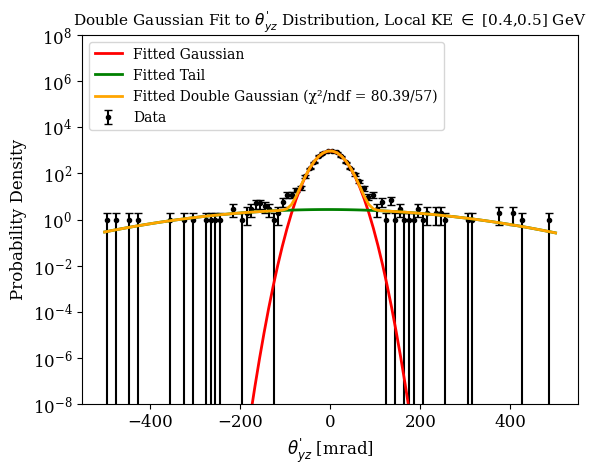

fraction            0.997110
mu                  0.300981
sigma              24.366554
mu_tail            -4.999987
sigma_tail        233.853967
fraction_err        0.000777
mu_err              0.325035
sigma_err           0.274875
mu_tail_err         9.260141
sigma_tail_err     77.821473
dtype: float64

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      80.3931
NDf                       =           57
Edm                       =  4.04157e-06
NCalls                    =          434
p0                        =      947.409   +/-   16.1798      	 (limited)
p1                        =      0.99711   +/-   0.000777077  	 (limited)
p2                        =     0.300981   +/-   0.325035     	 (limited)
p3                        =      24.3666   +/-   0.274875     	 (limited)
p4                        =     -4.99999   +/-   9.26014      	 (limited)
p5                        =      233.854   +/-   77.8215      	 (limited)


Warning in <TROOT::Append>: Replacing existing TH1: $\theta_{yz}^'$ (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [ ]:
def double_gaus_fit_5param(df,column,energyBounds=[],name="",core=False,tail=False,nbins=1000):
    plt.rc('font', family='serif', size=12)
    series = df[column]
    e1 = energyBounds[0]
    e2 = energyBounds[1]
    #parameters = [420.,0.98,0.,70.,0.,300.5]
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] >= e1 and muonEnergies[counter] <= e2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    func1 = TF1('func1', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
    #func1.SetParameters(410., 0.452, 70., 0.4972, 300.5) #[0.1,0.3 init]
    func1.SetParameters(250.,0.02,0.,20.,0.,1500.5)
    #func1.SetParameters(420., 0.98, 0., 70., 0., 400.5)  
    # fit range for scaling factor
    func1.SetParLimits(0, 0., 2000.)
    # fit ranges for area fraction 
    func1.SetParLimits(1, 0., 1.) #or try .5

    # fit ranges for sigma
    func1.SetParLimits(3, 0., 600.)
    func1.SetParLimits(5, 0., 1500.)

    #fit ranges for mu
    func1.SetParLimits(2, -5., 5.)
    func1.SetParLimits(4, -5., 5.)

    h_dtheta_xz = th1_from_series(seriesNew, name=name, nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
    #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
    print("Integral of histogram: ", h_dtheta_xz.Integral())
    h_dtheta_xz.Fit(func1, "S") #Fitting the double gaussian function to the data
   
    mu,sigma = func1.GetParameter(2), func1.GetParameter(3) #Getting the parameters of the fitted double gaussian function
    mu_tail,sigma_tail = func1.GetParameter(4), func1.GetParameter(5) #Getting the parameters of the fitted double gaussian function
    fraction,scale = func1.GetParameter(1), func1.GetParameter(0) #Getting the parameters of the fitted double gaussian function
    #Get Parameter Errors

    mu_err,sigma_err = func1.GetParError(2), func1.GetParError(3)
    mu_tail_err,sigma_tail_err = func1.GetParError(4), func1.GetParError(5)
    scale_err,fraction_err = func1.GetParError(0), func1.GetParError(1)

    #Getting fit results (chi squared, ndf)
    chi2 = func1.GetChisquare()
    ndf = func1.GetNDF()
    chi2_ndf = chi2/ndf

    bin_heights, bin_borders = np.histogram(seriesNew, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
    bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2
    plt.errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', gapcolor='purple', label='Data',markersize=3, capsize=3, linewidth=1.5, zorder=1)

    plt.yscale('log')

    x = np.linspace(-500, 500, nbins)
    pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
    pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
    double_pdf = pdf + pdf_tail
    
    if core: plt.plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
    if tail: plt.plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
    plt.plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian (χ²/ndf = {round(chi2,2)}/{ndf})', zorder=4)

    #change y axis 1000 more to fit legends
    plt.legend(loc='upper left', fontsize=10)
    plt.ylim(0.00000001,100000000)

    plt.xlabel(f"{name} [mrad]")
    plt.ylabel("Probability Density")
    plt.title(r"Double Gaussian Fit to " +name+ r" Distribution, Local KE $\in$ ["+ str(e1) + "," + str(e2) + "] GeV",size=11)
    #plt.tight_layout()

    plt.show()

    fitResult = pd.Series([fraction, mu, sigma, mu_tail, sigma_tail, fraction_err,mu_err, sigma_err, mu_tail_err, sigma_tail_err],index=['fraction', 'mu', 'sigma', 'mu_tail', 'sigma_tail', 'fraction_err', 'mu_err', 'sigma_err', 'mu_tail_err', 'sigma_tail_err'])

    return fitResult

dgaus_fitResult = double_gaus_fit_5param(muon_gen2, 'dtheta_yz_prime', energyBounds=[0.4, 0.5], name=r"$\theta_{yz}^'$",nbins=100,core=True,tail=True)
dgaus_fitResult    

# 3. Double Gaussian Subplots

In [ ]:
## This function takes user input. Updating code block below to take in a mutable array instead of user input.
def double_gaus_subplots_v1(df,column,energyBounds=[0.1,0.9],xname="",core=False,tail=False,nbins=1000):
    series = df[column]
    dgaus_parameters = pd.DataFrame()
    eb1 = energyBounds[0]
    eb2 = energyBounds[1]
    #print(eb2)
    eStep = 0.1
    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep
    #energyBins.append(eb2)
    print(energyBins)
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > eb1 and muonEnergies[counter] < eb2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    print(len(energyBins)-1)
    
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(25, 20),sharey=True)
    axs = axs.flatten()

    #parameters=[420.,0.98,0.,70.,0,300.5] -> Good init parameters for [0.1-0.3] GeV
    df_list = []
    for i in range(len(energyBins)-1):
        count = 0
        e1 = energyBins[i]
        e2 = energyBins[i+1]
        listNew2 = []
        parameterStr = input(f"Type your desired initial parameters for [{e1}-{e2}] GeV"+"\n"+"Make sure they're in the following order, each separated by a comma:"+"\n"+"Scale factor,Area fraction,mu1,sigma1,mu2,sigma2.")
        params = parameterStr.split(",")
        for j in range(len(params)):
            params[j] = float(params[j])
        #print(params)
        while count < len(seriesNew):
            if energyNew[count] >= e1 and energyNew[count] <= e2:
                listNew2.append(seriesNew[count])
            count += 1
        seriesNew2 = pd.Series(listNew2)
     
        func = TF1('func', ROOT.double_gaus_norm, -500, 500, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(params[0],params[1],params[2],params[3],params[4],params[5]) 
     
        #[0.1,0.3 init]
        #func1.SetParameters(420.,0.02,0.,70.,0,300.5) #0.02 area fraction works as opposed to 0.98- so I suppose this param is for the tail gaus.
    
        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0., 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 420.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(seriesNew2, name='roothist', nbins=nbins, xmin=-500, xmax=500) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data
   
        mu,sigma = func.GetParameter(2), func.GetParameter(3) #Getting the parameters of the fitted double gaussian function
        mu_tail,sigma_tail = func.GetParameter(4), func.GetParameter(5) #Getting the parameters of the fitted double gaussian function
        fraction,scale = func.GetParameter(1), func.GetParameter(0) #Getting the parameters of the fitted double gaussian function
        #Get Parameter Errors

        mu_err,sigma_err = func.GetParError(2), func.GetParError(3)
        mu_tail_err,sigma_tail_err = func.GetParError(4), func.GetParError(5)
        scale_err,fraction_err = func.GetParError(0), func.GetParError(1)

        #Getting fit results (chi squared, ndf)
        chi2 = func.GetChisquare()
        ndf = func.GetNDF()
        chi2_ndf = chi2/ndf

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=nbins, range=(-500, 500)) #Normalizing histogram to 1
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        plt.yscale('log')

        x = np.linspace(-500, 500, nbins)
        pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        x = np.linspace(-500, 500, nbins)
        pdf = scale * fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale * (1 - fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', label='Data',markersize=5, capsize=3, linewidth=1.5, zorder=1)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian \n'+r'$\chi^2$/NDf'+f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ "+f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')
        axs[i].legend(loc='upper left', fontsize=10)

        ser = pd.Series([fraction,mu,sigma,mu_tail,sigma_tail,fraction_err,mu_err,sigma_err,mu_tail_err,sigma_tail_err],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err'])
        df2 = pd.DataFrame({f"KE in [{e1}-{e2}]": ser})
        df_list.append(df2)

    #create dataframe with resulting fit parameters
    xvarCol = pd.Series([np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err']) #divider for each var
    xvarDf = pd.DataFrame({column:xvarCol})
    df_list.insert(0,xvarDf)
    dgaus_parameters = pd.concat(df_list,axis=1)

    
    #change y axis 1000 more to fit legends
    #axs[0].legend(loc='upper left', fontsize=10)
    axs[0].set_ylim(0.00000001,10000)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical',size='xx-large')
    plt.tight_layout
    plt.show()

    return dgaus_parameters

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
8
Integral of histogram:  6328.0
Integral of histogram:  11915.0
Integral of histogram:  9153.0
Integral of histogram:  5968.0
Integral of histogram:  3789.0
Integral of histogram:  1921.0
Integral of histogram:  968.0
Integral of histogram:  413.0


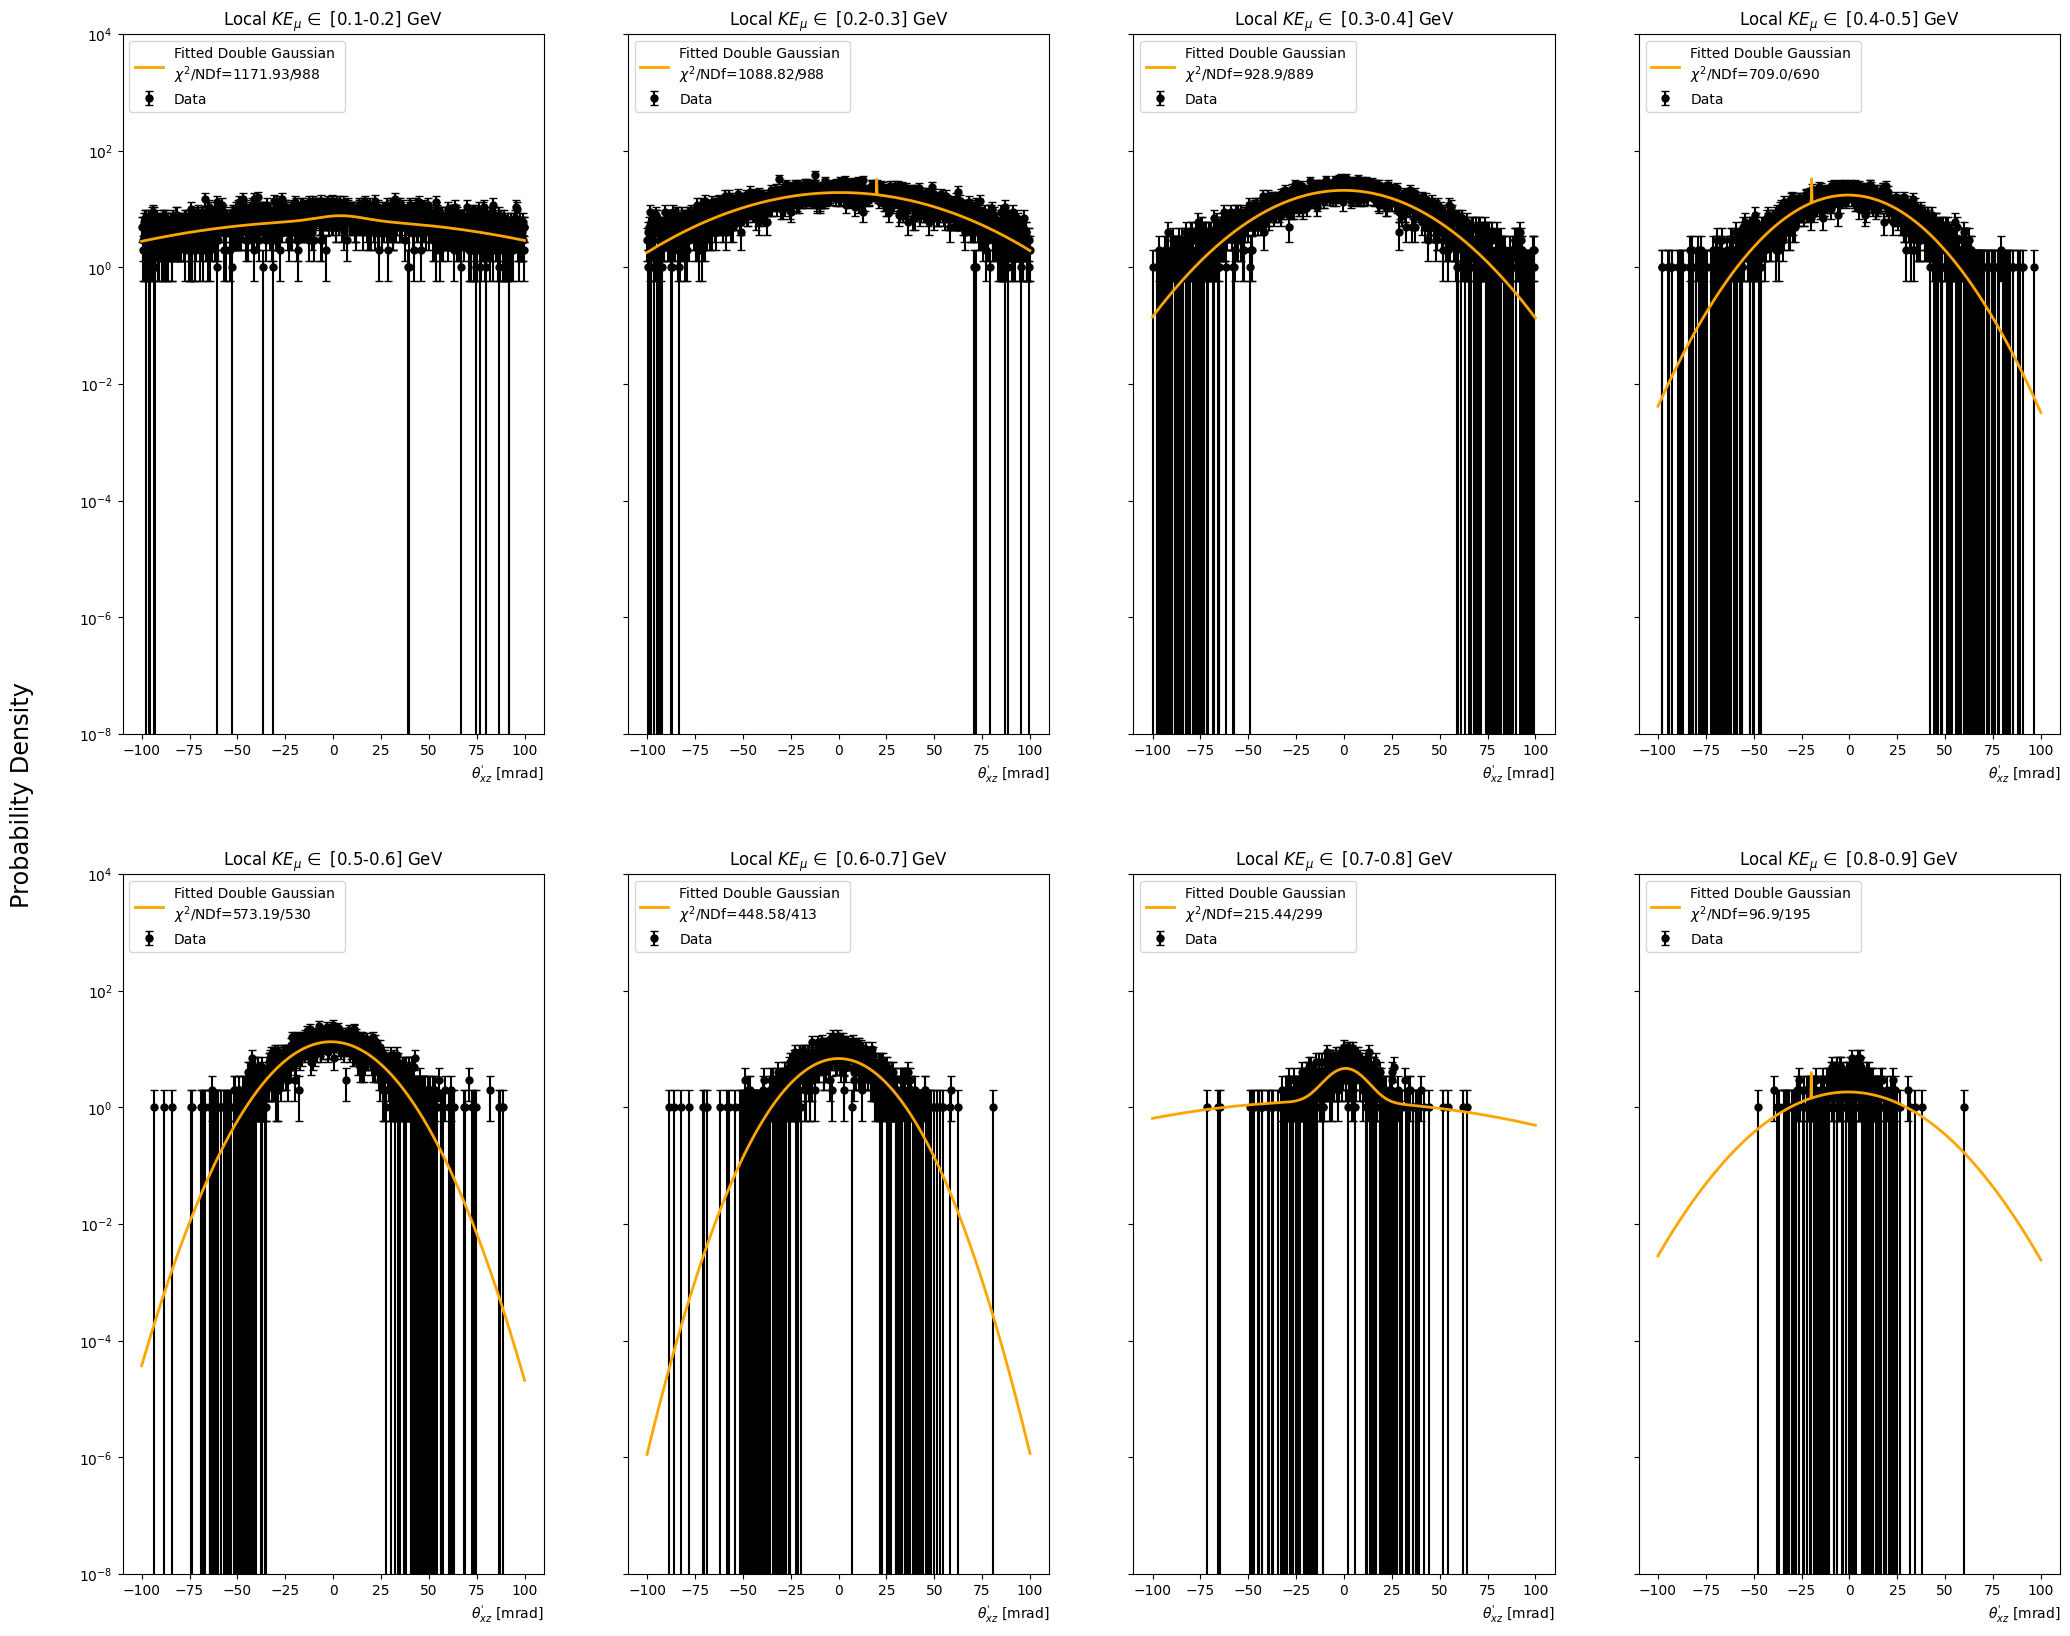

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
8
Integral of histogram:  8527.0
Integral of histogram:  12800.0
Integral of histogram:  9247.0
Integral of histogram:  5965.0
Integral of histogram:  3785.0
Integral of histogram:  1919.0
Integral of histogram:  968.0
Integral of histogram:  413.0


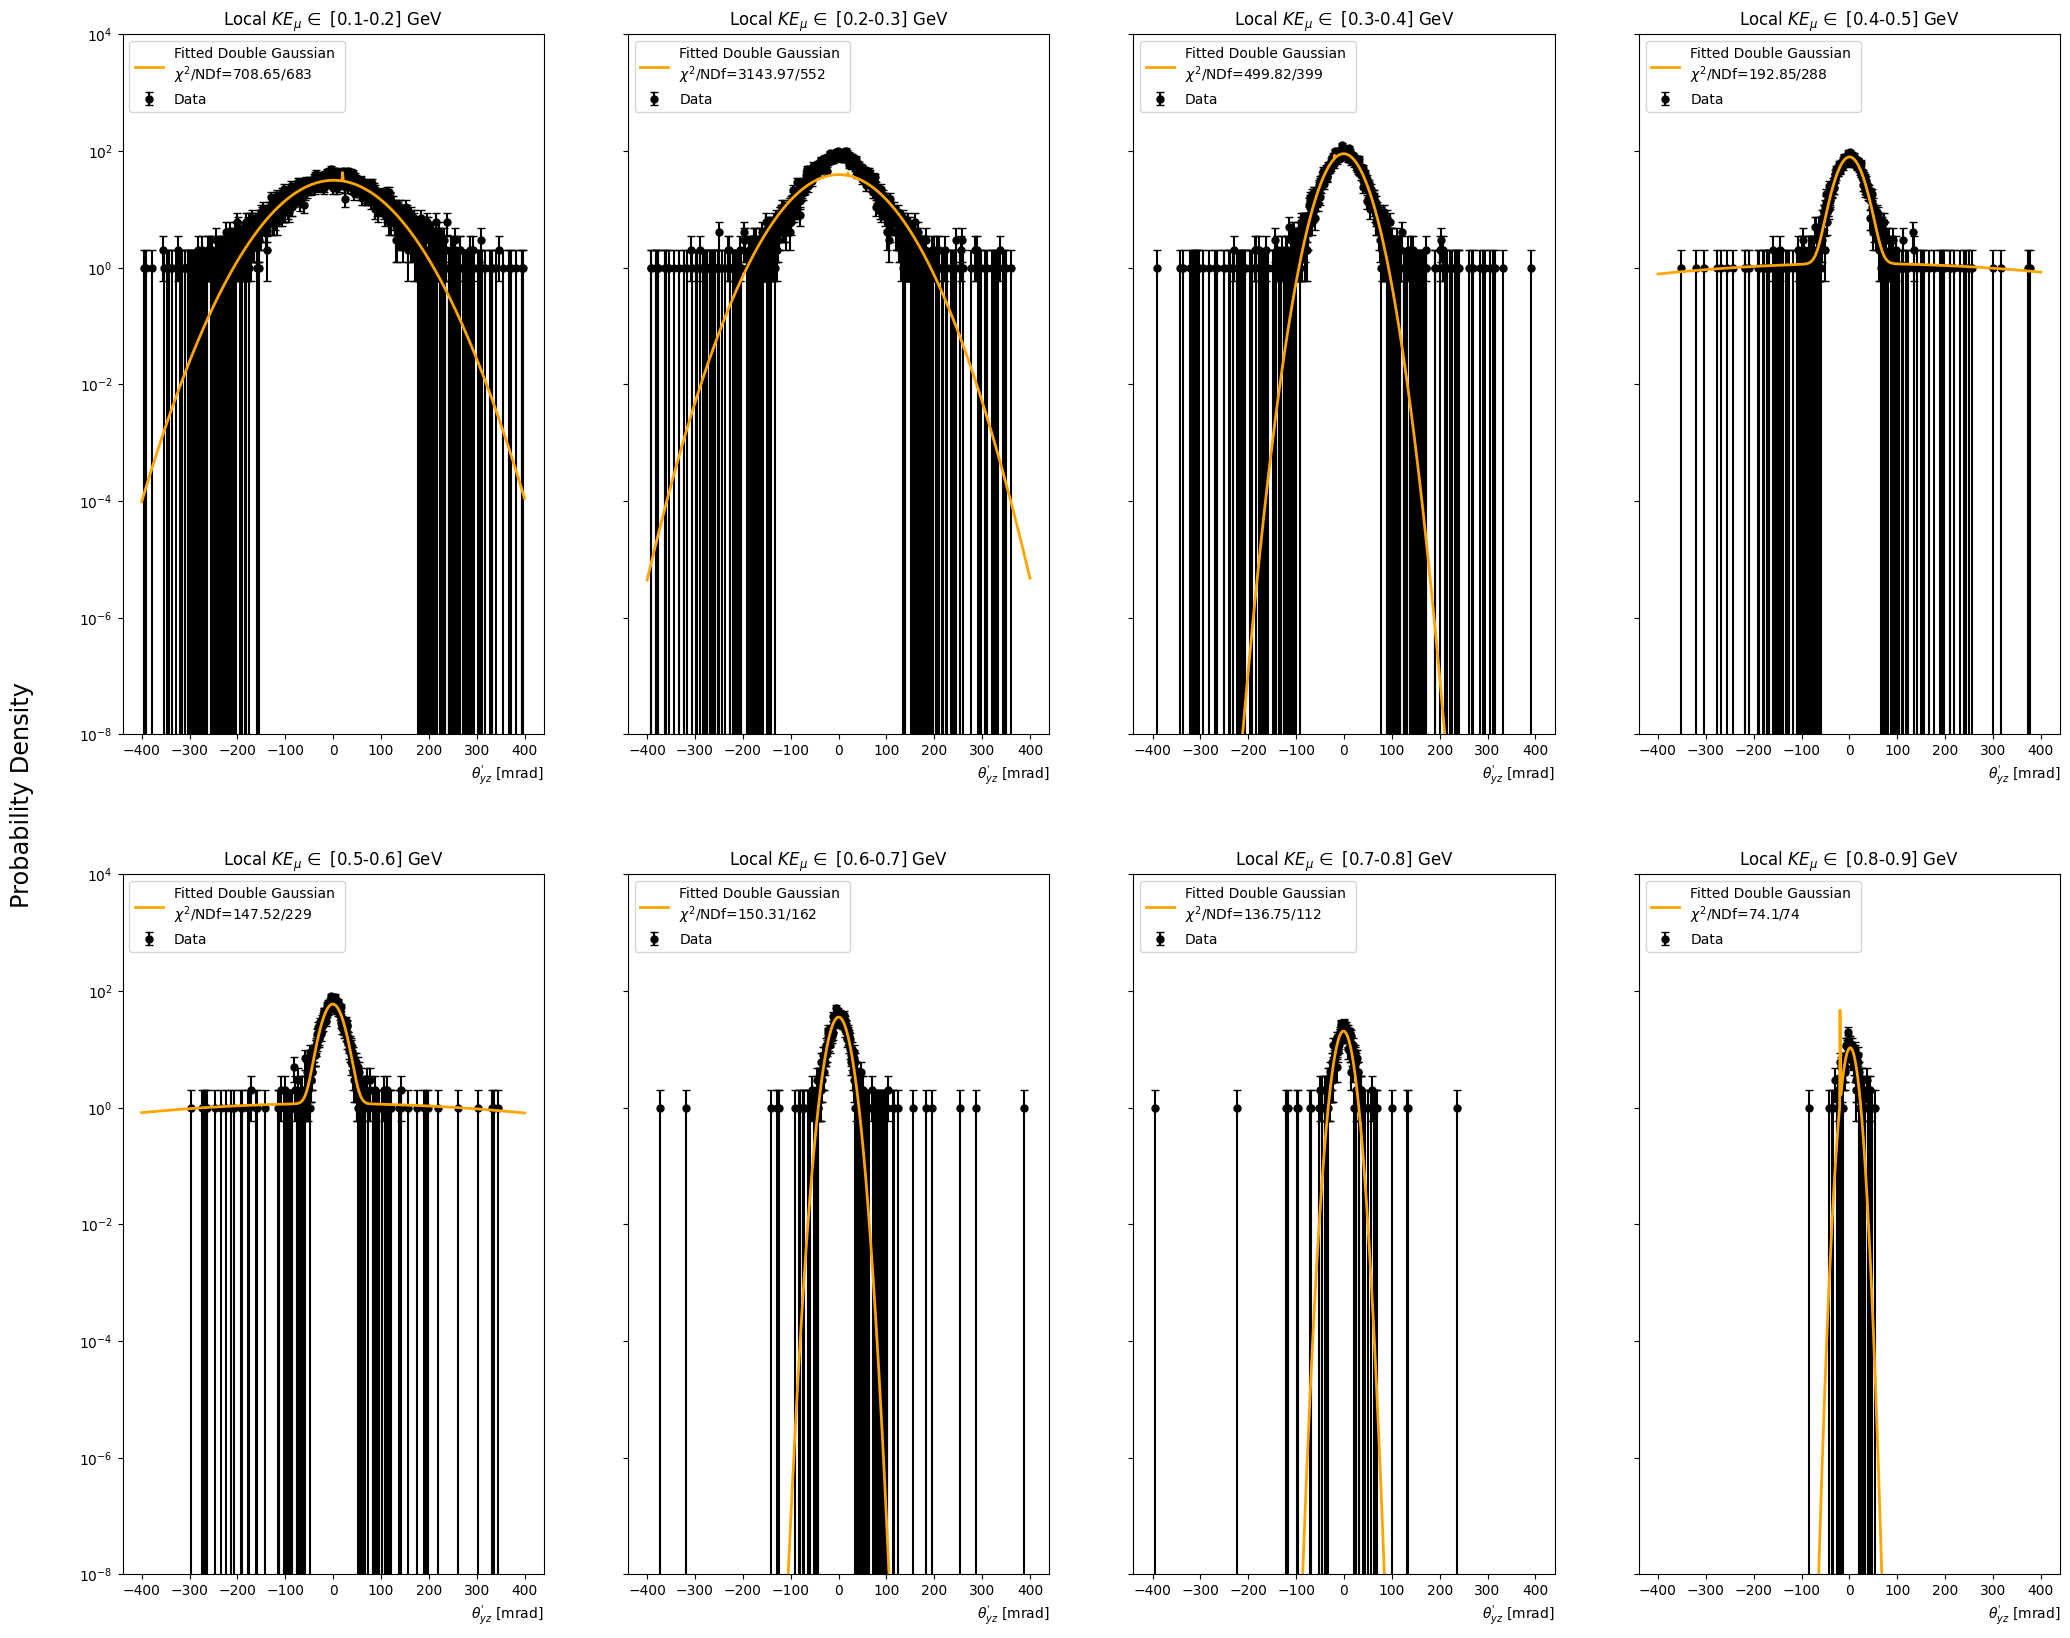

,dtheta_xz_prime,KE in [0.1-0.2],KE in [0.2-0.3],KE in [0.3-0.4],KE in [0.4-0.5],KE in [0.5-0.6],KE in [0.6-0.7],KE in [0.7-0.8],KE in [0.8-0.9],dtheta_yz_prime,KE in [0.1-0.2],KE in [0.2-0.3],KE in [0.3-0.4],KE in [0.4-0.5],KE in [0.5-0.6],KE in [0.6-0.7],KE in [0.7-0.8],KE in [0.8-0.9]
fraction,NaN,0.819007,0.186495,0.132843,0.188663,1.566132e-01,0.083733,0.270701,0.052522,NaN,0.219385,0.251534,0.229937,0.985155,0.980301,0.338524,1.673948e-01,0.099809
mu,NaN,0.969450,0.772844,-0.230067,-0.734152,-1.101952e+00,0.059646,-8.570656,-0.626663,NaN,1.068805,0.468827,-0.590011,0.276779,-0.686328,0.194777,-9.331222e-01,1.742811
sigma,NaN,79.297341,46.342676,31.577533,24.309399,1.955568e+01,17.900481,79.180627,27.633421,NaN,79.609128,70.777864,31.202297,22.367804,18.480858,15.884753,1.303087e+01,10.225691
mu_tail,NaN,4.055193,20.000000,-19.982920,-19.794115,1.999176e+01,-19.998982,0.908424,-19.996808,NaN,20.000000,19.984020,-19.867967,19.999919,-3.864376,-7.266136,1.997315e+01,-19.348559
sigma_tail,NaN,11.364115,0.042941,0.010688,0.045893,2.599841e-05,0.016375,9.116602,0.033843,NaN,0.180279,0.140603,0.095237,462.787723,467.843860,0.000100,6.980187e-07,0.222684
fraction_err,NaN,0.041696,0.025136,0.001705,0.036261,2.300597e-03,0.000450,0.049883,0.016924,NaN,0.884137,0.005134,0.008507,0.001809,0.002447,0.000000,5.396755e-03,0.913448
mu_err,NaN,1.753885,0.491022,0.297090,0.348703,3.680383e-01,0.105938,25.714335,2.987745,NaN,0.911806,0.014884,0.328158,0.321701,0.133187,0.000000,4.843282e-01,0.616265
sigma_err,NaN,3.490185,0.459488,0.227787,0.325421,3.700032e-01,0.083604,60.986449,5.299494,NaN,0.801911,0.100195,0.267850,0.268950,0.305963,0.000000,4.690797e-01,0.680185
mu_tail_err,NaN,3.056588,0.007697,29.410280,0.009739,2.872056e+01,30.951627,0.794048,25.829848,NaN,0.019055,0.001936,1.010065,35.344441,28.038624,0.000000,2.791762e+01,1.185352
sigma_tail_err,NaN,3.234551,0.005014,529.155006,0.005108,9.896526e-07,372.786195,0.980064,0.154219,NaN,0.210789,494.447549,0.261178,491.187645,350.440883,0.000000,2.082994e-05,0.596574


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1171.93
NDf                       =          988
Edm                       =  1.54028e-06
NCalls                    =         1385
p0                        =      7.71504   +/-   0.324343     	 (limited)
p1                        =     0.819007   +/-   0.0416955    	 (limited)
p2                        =      0.96945   +/-   1.75389      	 (limited)
p3                        =      79.2973   +/-   3.49019      	 (limited)
p4                        =      4.05519   +/-   3.05659      	 (limited)
p5                        =      11.3641   +/-   3.23455      	 (limited)
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      1088.82
NDf                       =          988
Edm                       =  7.85781e-06
NCalls                    =          361
p0                        =      103.194   +/-   13.9131      	 (limited)
p1          

Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warning in <TROOT::Append>: Replacing existing TH1: roothist (Potential memory leak).
Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 
Warnin

In [12]:
def double_gaus_subplots(df,column,energyBounds=[0.1,0.9],eStep=0.1,initParams=[],xrange=[-400,400],xname="",core=False,tail=False,nbins=1000):
    series = df[column]
    dgaus_parameters = pd.DataFrame()
    eb1 = energyBounds[0]
    eb2 = energyBounds[1]
    xmin = xrange[0]
    xmax = xrange[1]
    #print(eb2)
    #eStep = 0.1
    energyBins = []
    energy = eb1
    while energy < eb2:
        energyBins.append(round(energy, 2))
        energy += eStep
    #energyBins.append(eb2)
    print(energyBins)
    counter = 0
    energyNew = []
    dataNew = []
    #Performing a cut on the muon energies and dtheta_xz to only include those within the specified energy bin
    while counter < len(series):
        if muonEnergies[counter] > eb1 and muonEnergies[counter] < eb2:
            dataNew.append(series.values[counter])
            energyNew.append(muonEnergies[counter])
        counter += 1
    seriesNew = pd.Series(dataNew)

    print(len(energyBins)-1)
    
    fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(25, 20),sharey=True)
    axs = axs.flatten()

    #parameters=[420.,0.98,0.,70.,0,300.5] -> Good init parameters for [0.1-0.3] GeV
    df_list = []
    for i in range(len(energyBins)-1):
        count = 0
        initSubList = initParams[i]
        e1 = energyBins[i]
        e2 = energyBins[i+1]
        listNew2 = []
        #parameterStr = input(f"Type your desired initial parameters for [{e1}-{e2}] GeV"+"\n"+"Make sure they're in the following order, each separated by a comma:"+"\n"+"Scale factor,Area fraction,mu1,sigma1,mu2,sigma2.")
        #params = parameterStr.split(",")
        #for j in range(len(params)):
        #    params[j] = float(params[j])
        #print(params)
        while count < len(seriesNew):
            if energyNew[count] >= e1 and energyNew[count] <= e2:
                listNew2.append(seriesNew[count])
            count += 1
        seriesNew2 = pd.Series(listNew2)
     
        func = TF1('func', ROOT.double_gaus_norm, xmin, xmax, 6) #Create double gaussian function with 6 parameters, *Make a limit on params
        func.SetParameters(initSubList[0],initSubList[1],initSubList[2],initSubList[3],initSubList[4],initSubList[5]) 
     
        #[0.1,0.3 init]
        #func1.SetParameters(420.,0.02,0.,70.,0,300.5) #0.02 area fraction works as opposed to 0.98- so I suppose this param is for the tail gaus.
    
        # fit range for scaling factor
        func.SetParLimits(0, 0., 1000.)
        # fit range for area fraction 
        func.SetParLimits(1, 0., 1.) #or try .5

        # fit ranges for sigma1, sigma2
        func.SetParLimits(3, 0., 420.)
        func.SetParLimits(5, 0., 600.)

        #fit ranges for mu1, mu2
        func.SetParLimits(2, -20., 20.)
        func.SetParLimits(4, -20., 20.)

        #func1.setparlimits(3, 0.0, seriesNew.max()) #tail amplitude limit, make max the max y in histogram
        h_dtheta_xz = th1_from_series(seriesNew2, name='roothist', nbins=nbins, xmin=xmin, xmax=xmax) #Making TH1 Object to fit to the data
        #h_dtheta_xz.Scale(1./ h_dtheta_xz.Integral())
        print("Integral of histogram: ", h_dtheta_xz.Integral())
        h_dtheta_xz.Fit(func, "S") #Fitting the double gaussian function to the data
   
        mu,sigma = func.GetParameter(2), func.GetParameter(3) #Getting the parameters of the fitted double gaussian function
        mu_tail,sigma_tail = func.GetParameter(4), func.GetParameter(5) #Getting the parameters of the fitted double gaussian function
        fraction,scale = func.GetParameter(1), func.GetParameter(0) #Getting the parameters of the fitted double gaussian function
        #Get Parameter Errors

        mu_err,sigma_err = func.GetParError(2), func.GetParError(3)
        mu_tail_err,sigma_tail_err = func.GetParError(4), func.GetParError(5)
        scale_err,fraction_err = func.GetParError(0), func.GetParError(1)

        #Getting fit results (chi squared, ndf)
        chi2 = func.GetChisquare()
        ndf = func.GetNDF()
        chi2_ndf = chi2/ndf

        bin_heights, bin_borders = np.histogram(seriesNew2, bins=nbins, range=(xmin, xmax)) #Normalizing histogram to 1
        bin_centers = (bin_borders[:-1] + bin_borders[1:]) / 2

        plt.yscale('log')

        x = np.linspace(xmin, xmax, nbins)
        pdf = scale *fraction * np.exp(-0.5 * ((x - mu) / sigma) ** 2) #Probability for core gaus
        pdf_tail = scale*(1-fraction) * np.exp(-0.5 * ((x - mu_tail) / sigma_tail) ** 2) #Probability for tail gaus
        double_pdf = pdf + pdf_tail
        
        axs[i].errorbar(bin_centers, bin_heights, yerr=np.sqrt(bin_heights), fmt='o', color='black', label='Data',markersize=5, capsize=3, linewidth=1.5, zorder=1)
        axs[i].set_yscale('log')
        if core: axs[i].plot(x, pdf, color='red', linewidth=2, label='Fitted Gaussian',zorder=2)
        if tail: axs[i].plot(x, pdf_tail, color='green', linewidth=2, label='Fitted Tail',zorder=3)
        axs[i].plot(x, double_pdf, color='orange', linewidth=2, label=f'Fitted Double Gaussian \n'+r'$\chi^2$/NDf'+f"={round(chi2,2)}/{ndf}", zorder=4)
        axs[i].set_title(r"Local $KE_{\mu} \, \in$ "+f"[{e1}-{e2}] GeV")
        axs[i].set_xlabel(xname, loc='right')
        axs[i].legend(loc='upper left', fontsize=10)

        ser = pd.Series([fraction,mu,sigma,mu_tail,sigma_tail,fraction_err,mu_err,sigma_err,mu_tail_err,sigma_tail_err],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err'])
        df2 = pd.DataFrame({f"KE in [{e1}-{e2}]": ser})
        df_list.append(df2)

    #create dataframe with resulting fit parameters
    xvarCol = pd.Series([np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],index=['fraction','mu','sigma','mu_tail','sigma_tail','fraction_err','mu_err','sigma_err','mu_tail_err','sigma_tail_err']) #divider for each var
    xvarDf = pd.DataFrame({column:xvarCol})
    df_list.insert(0,xvarDf)
    dgaus_parameters = pd.concat(df_list,axis=1)

    
    #change y axis 1000 more to fit legends
    #axs[0].legend(loc='upper left', fontsize=10)
    axs[0].set_ylim(0.00000001,10000)
    fig.text(0.08, 0.5, 'Probability Density', va='center', rotation='vertical',size='xx-large')
    plt.tight_layout
    plt.show()

    return dgaus_parameters


xzPrime_initParams = [[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5],[150.,0.02,0.,60.,0.,600.5]]
yzPrime_initParams = [[250.,0.02,0.,100.,0.,900.5],[250.,0.02,0.,100.,0.,900.5],[250.,0.02,0.,100.,0.,900.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5],[250.,0.02,0.,20.,0.,1500.5]]


dgaus_fitResults_xzp = double_gaus_subplots(muon_gen2, 'dtheta_xz_prime', initParams=xzPrime_initParams,xname=r"$\theta_{xz}^'$ [mrad]",energyBounds=[0.1, 0.9], nbins=1000, xrange=[-100,100])
dgaus_fitResults_yzp = double_gaus_subplots(muon_gen2, 'dtheta_yz_prime', initParams=yzPrime_initParams, xname=r"$\theta_{yz}^'$ [mrad]",energyBounds=[0.1, 0.9], nbins=1000)
df_list = [dgaus_fitResults_xzp,dgaus_fitResults_yzp]
fitResults = pd.concat(df_list,axis=1)
fitResults

In [ ]:
420.,0.02,0.,70.,0,300.5 # params for muon_df [0.1,0.3] GeV
150.,0.02,0.,60.,0.,600.5 # params for muon_gen2 [0.1,0.3] GeV